In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from numpy import random

from InflGame.adaptive.visualization import Shell
import InflGame.utils.general as general
import InflGame.domains.rd as rd


## Resource distribution (beta)

In [4]:
#The resource points
bin_points=np.linspace(.001, .999, 100)





#resource parmaters
resource_parameters=[2,2] #alpha,beta

#Resource distribution
resource_distribution1=rd.resource_distribution_choice(bin_points=bin_points,resource_type='beta',resource_parameters=resource_parameters)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution1)
ax.set_box_aspect(1)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

## Resource distribution (Gaussian sym)

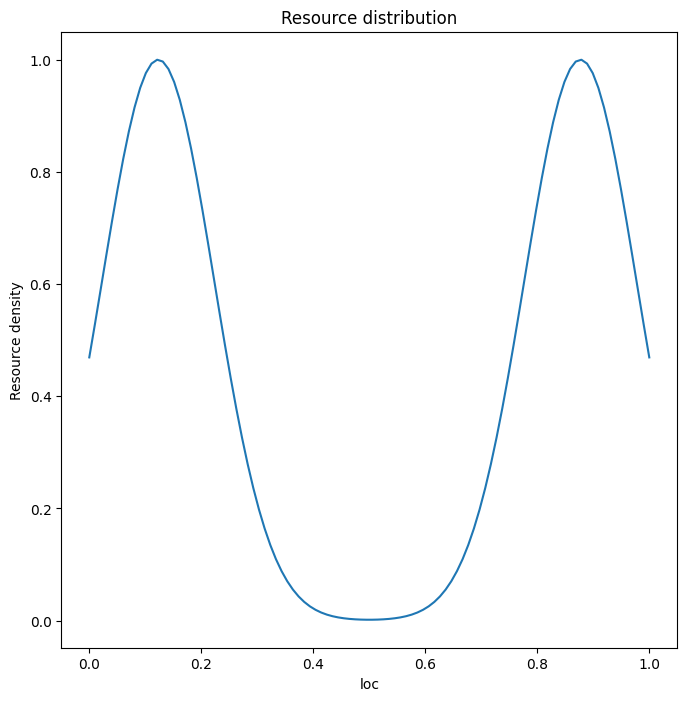

In [5]:
#The resource points
bin_points=np.linspace(.0001, 0.9999, 100)
alpha=0.7537688442211056
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.5-alpha/2,.5+alpha/2],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution2=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution2)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.show()


## Resource distribution (Gaussian asym)

In [6]:
#The resource points
bin_points=np.linspace(.001, .999, 100)
 
#Resource parameters
resource_parameters_gaussian_asym=[[.1,.1],[.25,.75],[1,.6]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution3=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian_asym)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution3)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

## Resource distribution (Noisy)

In [7]:
#The resource points
random.seed(1)
bin_points=np.linspace(.001, .999, 100)

#smoothing kernal (resource parameter)
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth
y=np.abs(random.uniform(low=0,high=1,size=100)+random.normal(loc=.5,scale=.1,size=100))

#Resource distribution
resource_distribution4=smooth(y,box_pts=20)
domain=bin_points

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution4)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
#fig.savefig('1d_bimodal_noisy.svg',bbox_inches='tight')
plt.close()

## Resource distribution (uniform)

In [8]:
#The resource points
bin_points=np.linspace(.0001, .9999, 100)
 
#Resource parameters
resource_parameters_gaussian=[[.1,.1],[.1,.5],[1,1]] #[[sd1, sd2,], [mean1,mean2], [factor1,factor2]]
#Resource distribution
resource_distribution5=rd.resource_distribution_choice(bin_points=bin_points,resource_type='multi_modal_gaussian_distribution_1D',resource_parameters=resource_parameters_gaussian)

#Plot
domain=bin_points
fig, ax = plt.subplots(figsize=(12, 8))
ax.plot(domain,resource_distribution5)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
ax.set_box_aspect(1) 
#fig.savefig('1d_bimodal_alpha_05.svg',bbox_inches='tight')
plt.close()

In [9]:
#The resource points
bin_points=np.linspace(.0001, .9999, 100)

resource_distribution6=np.array([1]*len(bin_points))

#Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_box_aspect(1)
ax.plot(domain,resource_distribution6)
plt.title('Resource distribution')
plt.xlabel('loc')
plt.ylabel('Resource density')
plt.close()

In [10]:
# bin_points=np.array([0,1])


# resource_distribution7=np.array([10,10])

# #Plot
# fig, ax = plt.subplots(figsize=(12, 8))
# ax.vlines(bin_points, 0, resource_distribution7, colors='b', lw=5)
# ax.set_box_aspect(1)
# ax.scatter(bin_points,resource_distribution7)
# plt.title('Resource distribution')
# plt.xlabel('loc')
# plt.ylabel('Resource density')


## Setup:The enviroment and adapative enviroment

The cell below sets up the outer shell for visualizing the the adapative enviroment. 

In [11]:

domain_type='1d'
resource_distribution=resource_distribution2
mean=np.dot(bin_points,resource_distribution)/np.sum(resource_distribution) #mean of the resource distribution




num_agents=4 #number of agents
#int_agents_pos=general.agent_position_setup(num_agents=num_agents,setup_type='paper_default',domain_type=domain_type,domain_bounds=0)
int_agents_pos=torch.tensor([.2,.25,.25,.8]) #initial agent positions

infl_configs={"infl_type":"gaussian"} # influence type of the agents


parameters=general.agent_parameter_setup(num_agents=num_agents,infl_type=infl_configs["infl_type"],setup_type="initial_symmetric_setup",reach=0.21) # parameters impacting agents reach (their std)
#parameters_custom=np.array([[.1,.2,.3,...]]) #needs to be length num_players


time_steps=20000# number steps for the adaptive dynamics


vis=Shell(num_agents=num_agents,agents_pos=int_agents_pos,parameters=parameters,resource_distribution=resource_distribution,bin_points=bin_points, 
infl_configs = infl_configs, learning_rate_type= 'cosine_annealing', learning_rate= [.0001, .0001, 500], time_steps=time_steps,
fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
tolerance = 10**-20, tolerated_agents = None,ignore_zero_infl= True)


vis.setup_adaptive_env()
vis.field.gradient_ascent()
og_pos_matrix=vis.field.pos_matrix
og_grad_matrix=vis.field.grad_matrix
vis.agents_pos=int_agents_pos.clone()
vis.field.agents_pos=int_agents_pos.clone()

        

#(0.158184517)


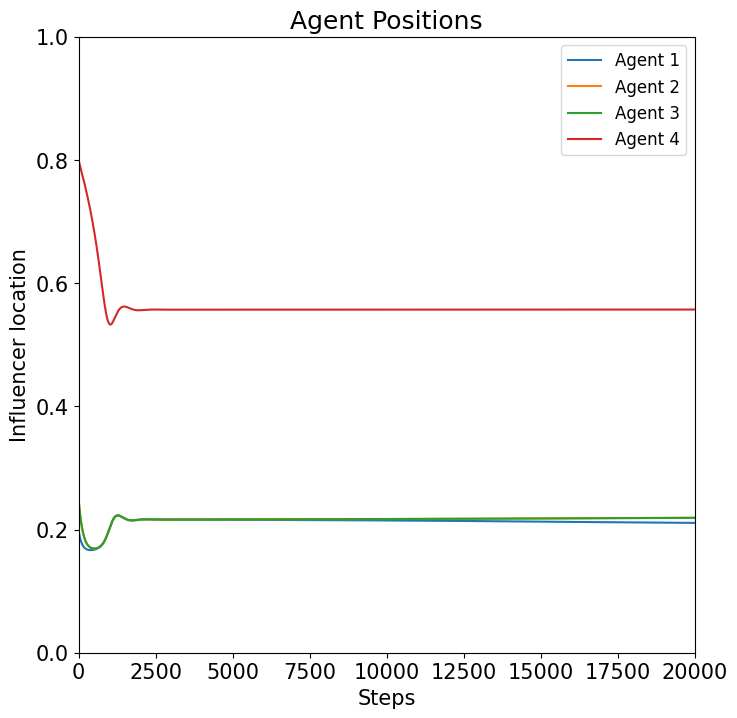

In [12]:
vis.pos_plot()

In [13]:
torch.round(vis.field.pos_matrix[-1],decimals=4)

tensor([0.2108, 0.2190, 0.2190, 0.5571])

In [14]:
resource_distribution_type="multi_modal_gaussian_distribution_1D"
alpha_current=.5
alpha_st=0
alpha_end = 1
varying_parameter_type='mean'
fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]]
num_points=200


resource_parameters,alpha=general.resource_parameter_setup(resource_distribution_type=resource_distribution_type,varying_parameter_type=varying_parameter_type,alpha_st=alpha_st, alpha_end=alpha_end, fixed_parameters_lst=fixed_parameters_lst,alpha_num_points=num_points)


In [15]:
from InflGame.adaptive.bifurcation_analysis import BifurcationEnv

In [16]:
bif_field=BifurcationEnv(vis.num_agents,vis.agents_pos,vis.parameters,vis.resource_distribution,vis.bin_points,
              vis.infl_configs,vis.learning_rate_type,vis.learning_rate,vis.time_steps,fp= 0, infl_cshift= False, cshift = 0, infl_fshift= False, Q = None,
              domain_type = '1d', domain_bounds = [0, 1], resource_type = 'na', domain_refinement = 10,
              tolerance = 10**-20, tolerated_agents = None,ignore_zero_infl= True)
bif_field.setup_adaptive_env()

In [17]:
import hickle as hkl
"""
test=bif_field.find_second_order_bifs(bin_points=bin_points,
                                      fixed_parameters_lst=fixed_parameters_lst,
                                      resource_distribution_type=resource_distribution_type,
                                      alpha_st=alpha_st,
                                      alpha_end=alpha_end,
                                      num_points=num_points,
                                      varying_parameter_type=varying_parameter_type,
                                      parallel=True,
                                      max_workers=8,
                                      batch_size=2,
                                      agents_pos=torch.Tensor([.4,.5,.5,.6]),
                                      time_steps=20000,
                                      learning_rate_p={'min':.00001,'max':.0001,'period':100,'min_simulated':.01},
                                      direct_method=True,)

test['final_parameters']=np.array(test['final_parameters'])
hkl.dump(test, 'gaussian_bif_4p.hkl')
"""

"\ntest=bif_field.find_second_order_bifs(bin_points=bin_points,\n                                      fixed_parameters_lst=fixed_parameters_lst,\n                                      resource_distribution_type=resource_distribution_type,\n                                      alpha_st=alpha_st,\n                                      alpha_end=alpha_end,\n                                      num_points=num_points,\n                                      varying_parameter_type=varying_parameter_type,\n                                      parallel=True,\n                                      max_workers=8,\n                                      batch_size=2,\n                                      agents_pos=torch.Tensor([.4,.5,.5,.6]),\n                                      time_steps=20000,\n                                      learning_rate_p={'min':.00001,'max':.0001,'period':100,'min_simulated':.01},\n                                      direct_method=True,)\n\ntest['final_parame

In [18]:

def bif_results_processing(test_results):
    """
    Process bifurcation results to ensure all dictionaries have uniform list lengths.
    
    Pads shorter lists with their last value. If a list is empty, uses the corresponding
    sigma_star value as padding. Also processes second_run data if it exists.
    
    :param test_results: Dictionary containing 'sigma_star' and 'final_parameters', 
                         and optionally 'final_parameters_2' for second run
    :return: Dictionary with processed 'unstable_flip' and 'stable_flip' as 2D arrays,
             and 'second_run' array if second run data exists
    """
    sigma_star_list = test_results['sigma_star']
    final_parameters = test_results['final_parameters']
    
    # Check if second run exists
    has_second_run = 'second_run' in test_results
    
    # Find the maximum length across all lists
    max_unstable_len = 0
    max_stable_len = 0
    
    for param_dict in final_parameters:
        if isinstance(param_dict, dict):
            max_unstable_len = max(max_unstable_len, len(param_dict.get('unstable_flip', [])))
            max_stable_len = max(max_stable_len, len(param_dict.get('stable_flip', [])))
    
    # Initialize output arrays
    num_params = len(final_parameters)
    unstable_flip_array = np.zeros((num_params, max(max_unstable_len, 1)))
    stable_flip_array = np.zeros((num_params, max(max_stable_len, 1)))
    
    # Process each parameter's dictionary
    for i, (param_dict, sigma_star) in enumerate(zip(final_parameters, sigma_star_list)):
        if isinstance(param_dict, dict):
            # Process unstable_flip
            unstable_list = param_dict.get('unstable_flip', [])
            if len(unstable_list) == 0:
                # If empty, fill with sigma_star
                unstable_flip_array[i, :] = sigma_star
            else:
                # Copy existing values
                unstable_flip_array[i, :len(unstable_list)] = unstable_list
                # Pad with last value
                if len(unstable_list) < max_unstable_len:
                    unstable_flip_array[i, len(unstable_list):] = unstable_list[-1]
            
            # Process stable_flip
            stable_list = param_dict.get('stable_flip', [])
            if len(stable_list) == 0:
                # If empty, fill with sigma_star
                stable_flip_array[i, :] = sigma_star
            else:
                # Copy existing values
                stable_flip_array[i, :len(stable_list)] = stable_list
                # Pad with last value
                if len(stable_list) < max_stable_len:
                    stable_flip_array[i, len(stable_list):] = stable_list[-1]
        else:
            # Handle non-dict entries (error cases)
            unstable_flip_array[i, :] = sigma_star
            stable_flip_array[i, :] = sigma_star
    
    # Build result dictionary
    result = {
        'sigma_star': sigma_star_list,
        'unstable_flip': unstable_flip_array,
        'stable_flip': stable_flip_array,
        'max_unstable_len': max_unstable_len,
        'max_stable_len': max_stable_len
    }
    
    # Process second run if it exists
    if has_second_run:
        final_parameters_2 = test_results['second_run']
        
        # Check if final_parameters_2 is already an array or needs processing
        if isinstance(final_parameters_2, np.ndarray):
            # Already processed - extract first column if 2D
            if final_parameters_2.ndim > 1:
                second_run_array = final_parameters_2[:, 0]
            else:
                second_run_array = final_parameters_2
        else:
            # Process list of values (from direct_method=False)
            second_run_array = np.array([
                param if not isinstance(param, (list, np.ndarray, torch.Tensor)) 
                else (param[0] if len(param) > 0 else sigma_star_list[i])
                for i, param in enumerate(final_parameters_2)
            ])
        
        result['second_run'] = second_run_array
    
    return result

# Process the bifurcation results
"""
test_processed = bif_results_processing(test)
hkl.dump(test_processed,'gaussian_bif_4p.hkl')
"""

"\ntest_processed = bif_results_processing(test)\nhkl.dump(test_processed,'gaussian_bif_4p.hkl')\n"

In [19]:
test_processed=hkl.load('gaussian_bif_4p.hkl')

In [20]:
def remove_outliers_bifurcation(data, method='zscore', threshold=3.0, window_size=5, replace_method='interpolate'):
    """
    Remove outliers from bifurcation data using various detection methods.
    
    :param data: 1D or 2D array of bifurcation data
    :type data: np.ndarray or torch.Tensor
    :param method: Outlier detection method - 'zscore', 'iqr', 'mad', or 'local_deviation'
    :type method: str
    :param threshold: Threshold for outlier detection (meaning varies by method)
    :type threshold: float
    :param window_size: Window size for local methods
    :type window_size: int
    :param replace_method: How to replace outliers - 'interpolate', 'median', 'mean', or 'neighbor'
    :type replace_method: str
    :return: Data with outliers removed/replaced
    :rtype: np.ndarray
    
    Methods:
    - 'zscore': Remove points > threshold standard deviations from mean
    - 'iqr': Remove points outside threshold * IQR from quartiles
    - 'mad': Median Absolute Deviation - robust to outliers
    - 'local_deviation': Compare each point to local window statistics
    
    Examples:
    >>> # Remove outliers using z-score
    >>> cleaned = remove_outliers_bifurcation(test_processed['split_31'], method='zscore', threshold=3.0)
    >>> 
    >>> # Use IQR method (more robust)
    >>> cleaned = remove_outliers_bifurcation(data, method='iqr', threshold=1.5)
    >>> 
    >>> # Local deviation for detecting sudden jumps
    >>> cleaned = remove_outliers_bifurcation(data, method='local_deviation', window_size=7, threshold=2.5)
    """
    from scipy.interpolate import interp1d
    from scipy.ndimage import median_filter
    
    # Convert to numpy array if needed
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    data = np.array(data, dtype=float)
    
    # Handle 1D and 2D cases
    if data.ndim == 1:
        data_to_clean = data.reshape(-1, 1)
        squeeze_output = True
    else:
        data_to_clean = data.copy()
        squeeze_output = False
    
    # Process each column
    cleaned = np.zeros_like(data_to_clean)
    
    for col_idx in range(data_to_clean.shape[1]):
        col_data = data_to_clean[:, col_idx].copy()
        n = len(col_data)
        
        # Detect outliers based on method
        is_outlier = np.zeros(n, dtype=bool)
        
        if method == 'zscore':
            # Z-score method: |x - mean| > threshold * std
            mean = np.mean(col_data)
            std = np.std(col_data)
            if std > 0:
                z_scores = np.abs((col_data - mean) / std)
                is_outlier = z_scores > threshold
                
        elif method == 'iqr':
            # Interquartile Range method
            q1 = np.percentile(col_data, 25)
            q3 = np.percentile(col_data, 75)
            iqr = q3 - q1
            lower_bound = q1 - threshold * iqr
            upper_bound = q3 + threshold * iqr
            is_outlier = (col_data < lower_bound) | (col_data > upper_bound)
            
        elif method == 'mad':
            # Median Absolute Deviation - very robust
            median = np.median(col_data)
            mad = np.median(np.abs(col_data - median))
            if mad > 0:
                modified_z_scores = 0.6745 * (col_data - median) / mad
                is_outlier = np.abs(modified_z_scores) > threshold
                
        elif method == 'local_deviation':
            # Local window-based detection
            for i in range(n):
                # Define local window
                start = max(0, i - window_size // 2)
                end = min(n, i + window_size // 2 + 1)
                window = col_data[start:end]
                
                # Remove current point from window for comparison
                window_no_point = np.concatenate([window[:i-start], window[i-start+1:]])
                if len(window_no_point) > 0:
                    local_median = np.median(window_no_point)
                    local_mad = np.median(np.abs(window_no_point - local_median))
                    
                    if local_mad > 0:
                        deviation = np.abs(col_data[i] - local_median) / local_mad
                        is_outlier[i] = deviation > threshold
        else:
            raise ValueError(f"Unknown method '{method}'. Choose from: 'zscore', 'iqr', 'mad', 'local_deviation'")
        
        # Replace outliers
        if np.any(is_outlier):
            if replace_method == 'interpolate':
                # Interpolate from non-outlier points
                valid_indices = np.where(~is_outlier)[0]
                if len(valid_indices) > 1:
                    interp_func = interp1d(valid_indices, col_data[valid_indices], 
                                          kind='linear', fill_value='extrapolate')
                    outlier_indices = np.where(is_outlier)[0]
                    col_data[outlier_indices] = interp_func(outlier_indices)
                    
            elif replace_method == 'median':
                # Replace with local median
                for i in np.where(is_outlier)[0]:
                    start = max(0, i - window_size // 2)
                    end = min(n, i + window_size // 2 + 1)
                    window = col_data[start:end]
                    valid_window = window[~is_outlier[start:end]]
                    if len(valid_window) > 0:
                        col_data[i] = np.median(valid_window)
                        
            elif replace_method == 'mean':
                # Replace with local mean
                for i in np.where(is_outlier)[0]:
                    start = max(0, i - window_size // 2)
                    end = min(n, i + window_size // 2 + 1)
                    window = col_data[start:end]
                    valid_window = window[~is_outlier[start:end]]
                    if len(valid_window) > 0:
                        col_data[i] = np.mean(valid_window)
                        
            elif replace_method == 'neighbor':
                # Replace with nearest non-outlier neighbor
                for i in np.where(is_outlier)[0]:
                    # Find nearest valid neighbor
                    left = i - 1
                    right = i + 1
                    while left >= 0 and is_outlier[left]:
                        left -= 1
                    while right < n and is_outlier[right]:
                        right += 1
                    
                    if left >= 0 and right < n:
                        col_data[i] = (col_data[left] + col_data[right]) / 2
                    elif left >= 0:
                        col_data[i] = col_data[left]
                    elif right < n:
                        col_data[i] = col_data[right]
        
        cleaned[:, col_idx] = col_data
    
    # Return with original shape
    if squeeze_output:
        return cleaned.squeeze()
    else:
        return cleaned

def remove_outliers_test_processed(test_processed, keys_to_clean=None, method='iqr', **kwargs):
    """
    Remove outliers from multiple arrays in a test_processed dictionary.
    
    :param test_processed: Dictionary containing bifurcation results
    :type test_processed: dict
    :param keys_to_clean: List of keys to clean (default: all bifurcation keys)
    :type keys_to_clean: list or None
    :param method: Outlier detection method to use
    :type method: str
    :param kwargs: Additional arguments to pass to remove_outliers_bifurcation
    :return: New dictionary with outliers removed
    :rtype: dict
    
    Example:
    >>> # Remove outliers using IQR method
    >>> test_cleaned = remove_outliers_test_processed(test_processed, method='iqr', threshold=1.5)
    >>> 
    >>> # Use local deviation for specific keys
    >>> test_cleaned = remove_outliers_test_processed(test_processed, 
    ...                                                keys_to_clean=['split_31', 'unstable_flip'],
    ...                                                method='local_deviation', 
    ...                                                threshold=3.0, 
    ...                                                window_size=7)
    """
    if keys_to_clean is None:
        keys_to_clean = ['unstable_flip', 'stable_flip', 'split_31', 'split_111', 'cycles_end', 'second_run']
    
    # Create a copy of the dictionary
    cleaned_dict = test_processed.copy()
    
    # Clean each specified key if it exists
    for key in keys_to_clean:
        if key in test_processed and test_processed[key] is not None:
            try:
                cleaned_dict[key] = remove_outliers_bifurcation(test_processed[key], method=method, **kwargs)
                print(f"Removed outliers from '{key}' using {method} method")
            except Exception as e:
                print(f"Warning: Could not clean '{key}': {e}")
                cleaned_dict[key] = test_processed[key]
    
    return cleaned_dict

In [21]:
def smooth_partial_data(data, start_idx=None, end_idx=None, method='savgol', window_size=11, poly_order=3, sigma=2.0):
    """
    Smooth only a specific portion of the data, leaving the rest unchanged.
    
    :param data: 1D or 2D array of data to partially smooth
    :type data: np.ndarray or torch.Tensor
    :param start_idx: Starting index for smoothing (None = from beginning)
    :type start_idx: int or None
    :param end_idx: Ending index for smoothing (None = to end)
    :type end_idx: int or None
    :param method: Smoothing method - 'savgol', 'gaussian', 'moving_average', or 'median'
    :type method: str
    :param window_size: Window size for smoothing
    :type window_size: int
    :param poly_order: Polynomial order for Savitzky-Golay filter
    :type poly_order: int
    :param sigma: Standard deviation for Gaussian filter
    :type sigma: float
    :return: Data with only specified region smoothed
    :rtype: np.ndarray
    
    Examples:
    >>> # Smooth only the first 150 points
    >>> smoothed = smooth_partial_data(test_processed['split_31'], start_idx=0, end_idx=150)
    >>> 
    >>> # Smooth everything except the last 45 points (equivalent to [:-45])
    >>> smoothed = smooth_partial_data(test_processed['split_31'], end_idx=-45)
    >>> 
    >>> # Smooth only the middle section
    >>> smoothed = smooth_partial_data(data, start_idx=50, end_idx=150, method='gaussian', sigma=3.0)
    >>> 
    >>> # Smooth from index 100 to the end
    >>> smoothed = smooth_partial_data(data, start_idx=100)
    """
    from scipy import signal
    from scipy.ndimage import gaussian_filter1d, median_filter
    
    # Convert to numpy array if needed
    if isinstance(data, torch.Tensor):
        data = data.cpu().numpy()
    data = np.array(data, dtype=float)
    
    # Handle 1D and 2D cases
    if data.ndim == 1:
        data_work = data.reshape(-1, 1)
        squeeze_output = True
    else:
        data_work = data.copy()
        squeeze_output = False
    
    # Create output array as copy of original
    result = data_work.copy()
    n = len(data_work)
    
    # Handle negative indices and None values
    if start_idx is None:
        start_idx = 0
    elif start_idx < 0:
        start_idx = n + start_idx
    
    if end_idx is None:
        end_idx = n
    elif end_idx < 0:
        end_idx = n + end_idx
    
    # Validate indices
    start_idx = max(0, min(start_idx, n))
    end_idx = max(0, min(end_idx, n))
    
    if start_idx >= end_idx:
        print(f"Warning: Invalid range [{start_idx}:{end_idx}]. Returning original data.")
        if squeeze_output:
            return result.squeeze()
        return result
    
    # Process each column
    for col_idx in range(data_work.shape[1]):
        # Extract the portion to smooth
        portion = data_work[start_idx:end_idx, col_idx]
        
        if len(portion) < 3:
            # Too short to smooth meaningfully
            continue
        
        # Apply smoothing method
        if method == 'savgol':
            # Adjust window size if portion is too small
            adj_window = min(window_size, len(portion) if len(portion) % 2 == 1 else len(portion) - 1)
            if adj_window >= poly_order + 2:
                smoothed_portion = signal.savgol_filter(portion, adj_window, poly_order)
            else:
                smoothed_portion = portion
                
        elif method == 'gaussian':
            smoothed_portion = gaussian_filter1d(portion, sigma=sigma)
            
        elif method == 'moving_average':
            adj_window = min(window_size, len(portion))
            kernel = np.ones(adj_window) / adj_window
            smoothed_portion = np.convolve(portion, kernel, mode='same')
            
        elif method == 'median':
            adj_window = min(window_size, len(portion))
            if adj_window % 2 == 0:
                adj_window -= 1
            smoothed_portion = median_filter(portion, size=adj_window)
            
        else:
            raise ValueError(f"Unknown method '{method}'. Choose from: 'savgol', 'gaussian', 'moving_average', 'median'")
        
        # Replace only the smoothed portion
        result[start_idx:end_idx, col_idx] = smoothed_portion
    
    # Return with original shape
    if squeeze_output:
        return result.squeeze()
    else:
        return result

def smooth_partial_test_processed(test_processed, key, start_idx=None, end_idx=None, 
                                   method='savgol', inplace=False, **kwargs):
    """
    Smooth a specific portion of a single array in test_processed dictionary.
    
    :param test_processed: Dictionary containing bifurcation results
    :type test_processed: dict
    :param key: Key of the array to partially smooth
    :type key: str
    :param start_idx: Starting index for smoothing (None = from beginning)
    :type start_idx: int or None
    :param end_idx: Ending index for smoothing (None = to end)
    :type end_idx: int or None
    :param method: Smoothing method to use
    :type method: str
    :param inplace: If True, modify the original dictionary; if False, return a copy
    :type inplace: bool
    :param kwargs: Additional arguments to pass to smooth_partial_data
    :return: Modified dictionary (new copy or reference to original if inplace=True)
    :rtype: dict
    
    Examples:
    >>> # Smooth split_31 except last 45 points
    >>> test_smoothed = smooth_partial_test_processed(test_processed, 'split_31', 
    ...                                                end_idx=-45, method='savgol')
    >>> 
    >>> # Smooth first 100 points of unstable_flip in place
    >>> smooth_partial_test_processed(test_processed, 'unstable_flip', 
    ...                                end_idx=100, inplace=True)
    >>> 
    >>> # Smooth middle section with custom parameters
    >>> test_smoothed = smooth_partial_test_processed(test_processed, 'split_111',
    ...                                                start_idx=50, end_idx=150,
    ...                                                method='gaussian', sigma=3.0)
    """
    if key not in test_processed:
        raise KeyError(f"Key '{key}' not found in test_processed")
    
    if test_processed[key] is None:
        print(f"Warning: test_processed['{key}'] is None. Returning unchanged.")
        return test_processed if inplace else test_processed.copy()
    
    # Perform smoothing
    smoothed_data = smooth_partial_data(test_processed[key], start_idx, end_idx, 
                                        method=method, **kwargs)
    
    # Update dictionary
    if inplace:
        test_processed[key] = smoothed_data
        print(f"Smoothed test_processed['{key}'][{start_idx}:{end_idx}] in place using {method} method")
        return test_processed
    else:
        result = test_processed.copy()
        result[key] = smoothed_data
        print(f"Smoothed test_processed['{key}'][{start_idx}:{end_idx}] using {method} method")
        return result

In [22]:
"""
test2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.16,.2,.2,.45]),
                                                second_order_bif= test_processed['unstable_flip'][:,0][-80:],
                                                guess_distance=.05,
                                                sig_edge=0.01,
                                                num_refinements=20,
                                                learning_rate_p={'min':.0001,'max':.0001,'outside_min':.0001,'outside_max':.0001,'period':500,'min_simulated':.0005},
                                                resource_distribution_type=resource_distribution_type,
                                                alpha_st=alpha[-80:][0],
                                                alpha_end=alpha_end,
                                                alpha_num_points=len(alpha[-80:]),
                                                varying_parameter_type=varying_parameter_type,
                                                fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]],
                                                parallel=True,
                                                time_steps=50000,
                                                learning_rate_type='inside_decay',
                                                method_type='bottom_up_n1')

t=test_processed['unstable_flip'][:-50][:,0]
test2=list(t)+list(np.array(test2[-50:])[:,0])
test2=np.array(test2)
test_processed['split_31']=test2

hkl.dump(test_processed,"gaussian_bif_4p.hkl")
"""

'\ntest2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.16,.2,.2,.45]),\n                                                second_order_bif= test_processed[\'unstable_flip\'][:,0][-80:],\n                                                guess_distance=.05,\n                                                sig_edge=0.01,\n                                                num_refinements=20,\n                                                learning_rate_p={\'min\':.0001,\'max\':.0001,\'outside_min\':.0001,\'outside_max\':.0001,\'period\':500,\'min_simulated\':.0005},\n                                                resource_distribution_type=resource_distribution_type,\n                                                alpha_st=alpha[-80:][0],\n                                                alpha_end=alpha_end,\n                                                alpha_num_points=len(alpha[-80:]),\n                                                varying_parameter_type=v

In [23]:
smoothed = remove_outliers_bifurcation(test_processed['split_31'],method='zscore', threshold=1.7)
original = smoothed.copy()
bound = -59
# Smooth only the last 45 points (start_idx=-55 means start from 55 points from the end)
partially_smoothed = smooth_partial_data(original, start_idx=bound, method='gaussian', 
                                         window_size=15, poly_order=2,sigma=1.0)

In [24]:
"""
test2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.16,.2,.2,.45]),
                                                second_order_bif= partially_smoothed[-80:],
                                                guess_distance=.02,
                                                sig_edge=0.01,
                                                num_refinements=20,
                                                learning_rate_p={'min':.0001,'max':.0001,'outside_min':.0001,'outside_max':.0001,'period':500,'min_simulated':.00001},
                                                resource_distribution_type=resource_distribution_type,
                                                alpha_st=alpha[-80:][0],
                                                alpha_end=alpha_end,
                                                alpha_num_points=len(alpha[-80:]),
                                                varying_parameter_type=varying_parameter_type,
                                                fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]],
                                                parallel=True,
                                                time_steps=50000,
                                                learning_rate_type='inside_decay',
                                                method_type='bottom_up_n1')

t=test_processed['unstable_flip'][:-50][:,0]
test2=list(t)+list(np.array(test2[-50:]))
test2=np.array(test2)
test_processed['split_31']=test2

hkl.dump(test_processed,"gaussian_bif_4p.hkl")
"""

'\ntest2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.16,.2,.2,.45]),\n                                                second_order_bif= partially_smoothed[-80:],\n                                                guess_distance=.02,\n                                                sig_edge=0.01,\n                                                num_refinements=20,\n                                                learning_rate_p={\'min\':.0001,\'max\':.0001,\'outside_min\':.0001,\'outside_max\':.0001,\'period\':500,\'min_simulated\':.00001},\n                                                resource_distribution_type=resource_distribution_type,\n                                                alpha_st=alpha[-80:][0],\n                                                alpha_end=alpha_end,\n                                                alpha_num_points=len(alpha[-80:]),\n                                                varying_parameter_type=varying_parameter_ty

In [25]:
"""
test2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.5,.55,.55,.6]),
                                                second_order_bif= test_processed['split_31'],
                                                guess_distance=.1,
                                                sig_edge=0.01,
                                                num_refinements=10,
                                                learning_rate_p={'min':.0001,'max':.0001,'outside_min':.01,'outside_max':.01,'period':500,'min_simulated':.0001},
                                                resource_distribution_type=resource_distribution_type,
                                                alpha_st=alpha[0],
                                                alpha_end=alpha_end,
                                                alpha_num_points=len(alpha),
                                                varying_parameter_type=varying_parameter_type,
                                                fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]],
                                                parallel=True,
                                                time_steps=50000,
                                                method_type='top_down',
                                                learning_rate_type='inside_decay')

test2=np.array(test2)
test_processed['split_111']=test2[:,0]
"""

"\ntest2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.5,.55,.55,.6]),\n                                                second_order_bif= test_processed['split_31'],\n                                                guess_distance=.1,\n                                                sig_edge=0.01,\n                                                num_refinements=10,\n                                                learning_rate_p={'min':.0001,'max':.0001,'outside_min':.01,'outside_max':.01,'period':500,'min_simulated':.0001},\n                                                resource_distribution_type=resource_distribution_type,\n                                                alpha_st=alpha[0],\n                                                alpha_end=alpha_end,\n                                                alpha_num_points=len(alpha),\n                                                varying_parameter_type=varying_parameter_type,\n                       

In [26]:
"""
test2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.51,.55,.6]),
                                                second_order_bif= test_processed['unstable_flip'][:, 0],
                                                guess_distance=.1,
                                                sig_edge=0.01,
                                                num_refinements=20,
                                                learning_rate_p={'min':.00001,'max':.0001,'period':100,'min_simulated':.01},
                                                resource_distribution_type=resource_distribution_type,
                                                alpha_st=alpha_st,
                                                alpha_end=alpha_end,
                                                alpha_num_points=num_points,
                                                varying_parameter_type=varying_parameter_type,
                                                fixed_parameters_lst=[resource_parameters_gaussian[0],resource_parameters_gaussian[2]],
                                                parallel=True,
                                                max_workers=8,
                                                batch_size=4,
                                                time_steps=10000)

test_processed['cycles_end']=np.array(test2)         
"""                                

"\ntest2=bif_field.find_third_order_bifurcations_refined(int_position=torch.tensor([.51,.55,.6]),\n                                                second_order_bif= test_processed['unstable_flip'][:, 0],\n                                                guess_distance=.1,\n                                                sig_edge=0.01,\n                                                num_refinements=20,\n                                                learning_rate_p={'min':.00001,'max':.0001,'period':100,'min_simulated':.01},\n                                                resource_distribution_type=resource_distribution_type,\n                                                alpha_st=alpha_st,\n                                                alpha_end=alpha_end,\n                                                alpha_num_points=num_points,\n                                                varying_parameter_type=varying_parameter_type,\n                                                fixe

In [43]:

import matplotlib.patches as mpatches
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
from typing import List, Tuple, Dict, Optional
import matplotlib.figure

from InflGame.utils import data_management
def first_order_bifurcation_plot(infl_type: str = 'gaussian',
                                 alpha_st: float = 0,
                                 alpha_end: float = 1,
                                 test_processed = None,
                                 alpha_values = None,
                                 cutoff_index = None,
                                 title_ads: List[str] = [],
                                 save: bool = False,
                                 name_ads: List[str] = [],
                                 font = {'default_size': 15, 'cbar_size': 16, 'title_size': 18, 'legend_size': 12, 'table_size':15,'label_size':10,'font_family': 'sans-serif',},
                                 save_types: List[str] = ['.png', '.svg'],
                                 paper_figure: dict= {'paper':False,'section':'3_2_6','figure_id':'bif_diag'}
                                ) -> matplotlib.figure.Figure:
    r"""
        Plots the first-order bifurcation for agents over a range of alpha values (resource parameters) via func:`jacobian_stability_fast`. 
        
        Now supports both original format (Gaussian) and new beta format with processed stability flips.

        **Gaussian example**

        .. figure:: examples/first_order.png
            :scale: 75 %

            This is a first order bifurcations plot for 5 players using symmetric Gaussian influence kernels.
                

        :param agent_parameter_instance: Parameters for the influence function.
        :type agent_parameter_instance: Union[List[float], np.ndarray]
        :param resource_distribution_type: Type of resource distribution.
        :type resource_distribution_type: str
        :param resource_entropy: Whether to calculate resource entropy.
        :type resource_entropy: bool
        :param infl_entropy: Whether to calculate influence entropy.
        :type infl_entropy: bool
        :param alpha_current: Current alpha value.
        :type alpha_current: float
        :param alpha_st: Starting value of alpha.
        :type alpha_st: float
        :param alpha_end: Ending value of alpha.
        :type alpha_end: float
        :param varying_paramter_type: Type of varying parameter (e.g., 'mean').
        :type varying_paramter_type: str
        :param fixed_parameters_lst: List of fixed parameters.
        :type fixed_parameters_lst: Optional[List[float]]
        :param name_ads: Additional names for saved files.
        :type name_ads: List[str]
        :param title_ads: Additional titles for the plot.
        :type title_ads: List[str]
        :param save_types: File types to save the plot.
        :type save_types: List[str]
        :param test_processed: Processed test results with 'unstable_flip', 'stable_flip', and optionally 'cycles_end'
        :type test_processed: Optional[dict]
        :param alpha_values: Alpha values array
        :type alpha_values: Optional[np.ndarray]
        :param cutoff_index: Index to cutoff the data
        :type cutoff_index: Optional[int]

        :return: The generated plot figure.
        :rtype: matplotlib.figure.Figure
        """


                             
    
    font['font.family'] = font.get('font_family', 'sans-serif')
    cbar_font_size= font.get('cbar_size', 12)
    default_font_size = font.get('default_size', 12)
    title_font_size = font.get('title_size', 14)
    legend_font_size = font.get('legend_size', 12)
    table_font_size = font.get('table_size',12)
    label_font_size = font.get('label_size',10)
    mpl.rcParams.update({'font.size': default_font_size, 'font.family': font['font.family']})
    mpl.rcParams['legend.fontsize'] = legend_font_size
    
    fig,ax=plt.subplots(figsize=(24, 16))
    ax.set_box_aspect(1)
    
    # Apply font settings
    plt.rcParams.update({'font.size': font['default_size'], 'font.family': font['font_family']})
    
    # Determine which format we're using
    # Original Gaussian case: using test['final_parameters'] as arrays
    if alpha_values is None:
            raise ValueError("alpha_values must be provided when using test_processed")
        
    if cutoff_index is None:
            cutoff_index = len(alpha_values)
    
    alpha = alpha_values[:cutoff_index]
    y = test_processed['sigma_star'][:cutoff_index]
    z = test_processed['unstable_flip'][:cutoff_index, 0]
    
    # Check if cycles_end exists in test_processed
    has_cycles = 'cycles_end' in test_processed and test_processed['cycles_end'] is not None
    
    # Plot sigma_star and unstable flip
    ax.plot(alpha, y, label=r'$\sigma^{*}_0$ exact', color='black')
    ax.fill_between(alpha, y, max(max(y), .3), where=(alpha <= alpha_end), color='#87CEEB', alpha=0.5)  # Sky blue for symmetric Nash
    
    if infl_type == 'beta':
        # If stable flip exists, add it
        if test_processed['max_stable_len'] > 0:
            w = test_processed['stable_flip'][:cutoff_index, 0]
            ax.plot(alpha, w, label=r'$\sigma^{*}_1$ est.', color='black', linestyle='dashdot')
            ax.fill_between(alpha, w, y, where=(alpha >= alpha_st), color='#FF6B6B', alpha=0.5)  # Coral red for 2-1
            ax.fill_between(alpha, z, w, where=(alpha >= alpha_st), color='#9370DB', alpha=0.5)  # Medium purple for 1-1-1
        else:
            ax.fill_between(alpha, 0, z, where=(alpha >= alpha_st), color='#FF6B6B', alpha=0.5)  # Coral red for 2-1
        ax.plot(alpha, z, label=r'$\sigma^{*}_2$ est.', color='black', linestyle='--')
        
        # Fill regions with improved colors
        if has_cycles:
            # Handle both 1D and 2D arrays for cycles_end
            cycles_data = test_processed['cycles_end']
            if isinstance(cycles_data, np.ndarray) and cycles_data.ndim > 1:
                w = cycles_data[:cutoff_index].flatten() if cycles_data.shape[1] == 1 else cycles_data[:cutoff_index, 0]
            else:
                w = np.array(cycles_data)[:cutoff_index]
            ax.plot(alpha, w, label=r'$\sigma^{*}_3$ est.', color='black', linestyle='dotted')
            ax.fill_between(alpha, w, z, where=(alpha >= alpha_st), color='#FFD700', alpha=0.5)  # Gold for cycle
            ax.fill_between(alpha, 0, w, where=(alpha >= alpha_st), color='#FF6B6B', alpha=0.5)  # Coral red for 2-1
        
    
    else:
        if num_agents==4:
            # Gaussian case: Fill regions with improved colors
            ax.fill_between(alpha, y, z, where=(alpha >= alpha_st), color='#9370DB', alpha=0.5)
            ax.plot(alpha, z, label=r'$\sigma^{*}_1$ est.', color='black', linestyle='--')
            ax.fill_between(alpha, 0, z,where=(alpha >= alpha_st), color="#388001", alpha=0.5)
            ax.fill_between(alpha, 0, y,where=(alpha >= alpha_st), facecolor='none', edgecolor="#090909", hatch='\\\\\\', linewidth=0)
                
        else:
            # Gaussian case: Fill regions with improved colors
            ax.fill_between(alpha, y, z, where=(alpha >= alpha_st), color='#9370DB', alpha=0.5)
            ax.plot(alpha, z, label=r'$\sigma^{*}_1$ est.', color='black', linestyle='--')
            
            if has_cycles:
                # Handle both 1D and 2D arrays for cycles_end
                cycles_data = test_processed['cycles_end']
                if isinstance(cycles_data, np.ndarray) and cycles_data.ndim > 1:
                    w = cycles_data[:cutoff_index].flatten() if cycles_data.shape[1] == 1 else cycles_data[:cutoff_index, 0]
                else:
                    w = np.array(cycles_data)[:cutoff_index]
                ax.plot(alpha, w, label=r'$\sigma^{*}_2$ est.', color='black', linestyle='dotted')
                ax.fill_between(alpha, w, z, where=(alpha >= alpha_st), color='#FFD700', alpha=0.5)  # Gold for cycle
                ax.fill_between(alpha, 0, w, where=(alpha >= alpha_st), color='#FF6B6B', alpha=0.5)  # Coral red for 2-1
        
    
    plt.ylim(0, max(max(y), .3))
    
    # Legend patches with improved colors
    red_p = mpatches.Patch(color='#FF6B6B', alpha=0.5, label=f'({num_agents-1},1) or (1,{num_agents-1})')
    yellow_p = mpatches.Patch(color='#FFD700', alpha=0.5, label='cycle')
    purple_p = mpatches.Patch(color='#9370DB', alpha=0.5, label=f'(1,{num_agents-2},1)')
    blue_p = mpatches.Patch(color='#87CEEB', alpha=0.5, label=r'sym nash')
    green_p = mpatches.Patch(color='#388001', alpha=0.5, label=r'Mixed results')
    black_p = mpatches.Patch(facecolor='white', edgecolor='#090909', hatch='\\\\\\', label='(2,2) dom')
    old_handles, labels = ax.get_legend_handles_labels()
    
    # Conditionally add legend patches based on what's plotted
    legend_handles = [blue_p]
    if infl_type == 'beta':
        legend_handles.append(red_p)
        legend_handles.append(purple_p)
        if has_cycles:
            legend_handles.append(yellow_p)
    else:
        if num_agents==4:
            legend_handles.append(black_p)
            legend_handles.append(purple_p)
            legend_handles.append(green_p)
        else:
            legend_handles.append(purple_p)
        if has_cycles:
            legend_handles.append(yellow_p)
            legend_handles.append(red_p)
        
        

    
    plt.legend(handles=legend_handles + old_handles)
    plt.ylabel("$\sigma$ (reach)", fontsize=font['default_size'])
    plt.xlabel(r"$\alpha$ (mode distance)", fontsize=font['default_size'])
    
    title = r"$(\alpha,\sigma)$ $x^{*}$ stability bifurication for " + str(vis.num_agents) + " players"
    if len(title_ads) > 0:
        for title_additon in title_ads:
            title = title + " " + title_additon
    plt.title(title, fontsize=font['title_size'])
    plt.xlim(alpha_st, alpha[cutoff_index-1]) 
    plt.close()
    if save==True:
        file_names=data_management.data_final_name({'data_type':'plot',"plot_type":'bif_diagram','domain_type':vis.domain_type,'num_agents':vis.num_agents,'section':paper_figure['section'],'figure_id':paper_figure.get('figure_id','bif_diagram')},name_ads=name_ads,save_types=save_types,paper_figure=paper_figure['paper'])
        for file_name in file_names:
            fig.savefig(file_name,bbox_inches='tight')
        
    return fig


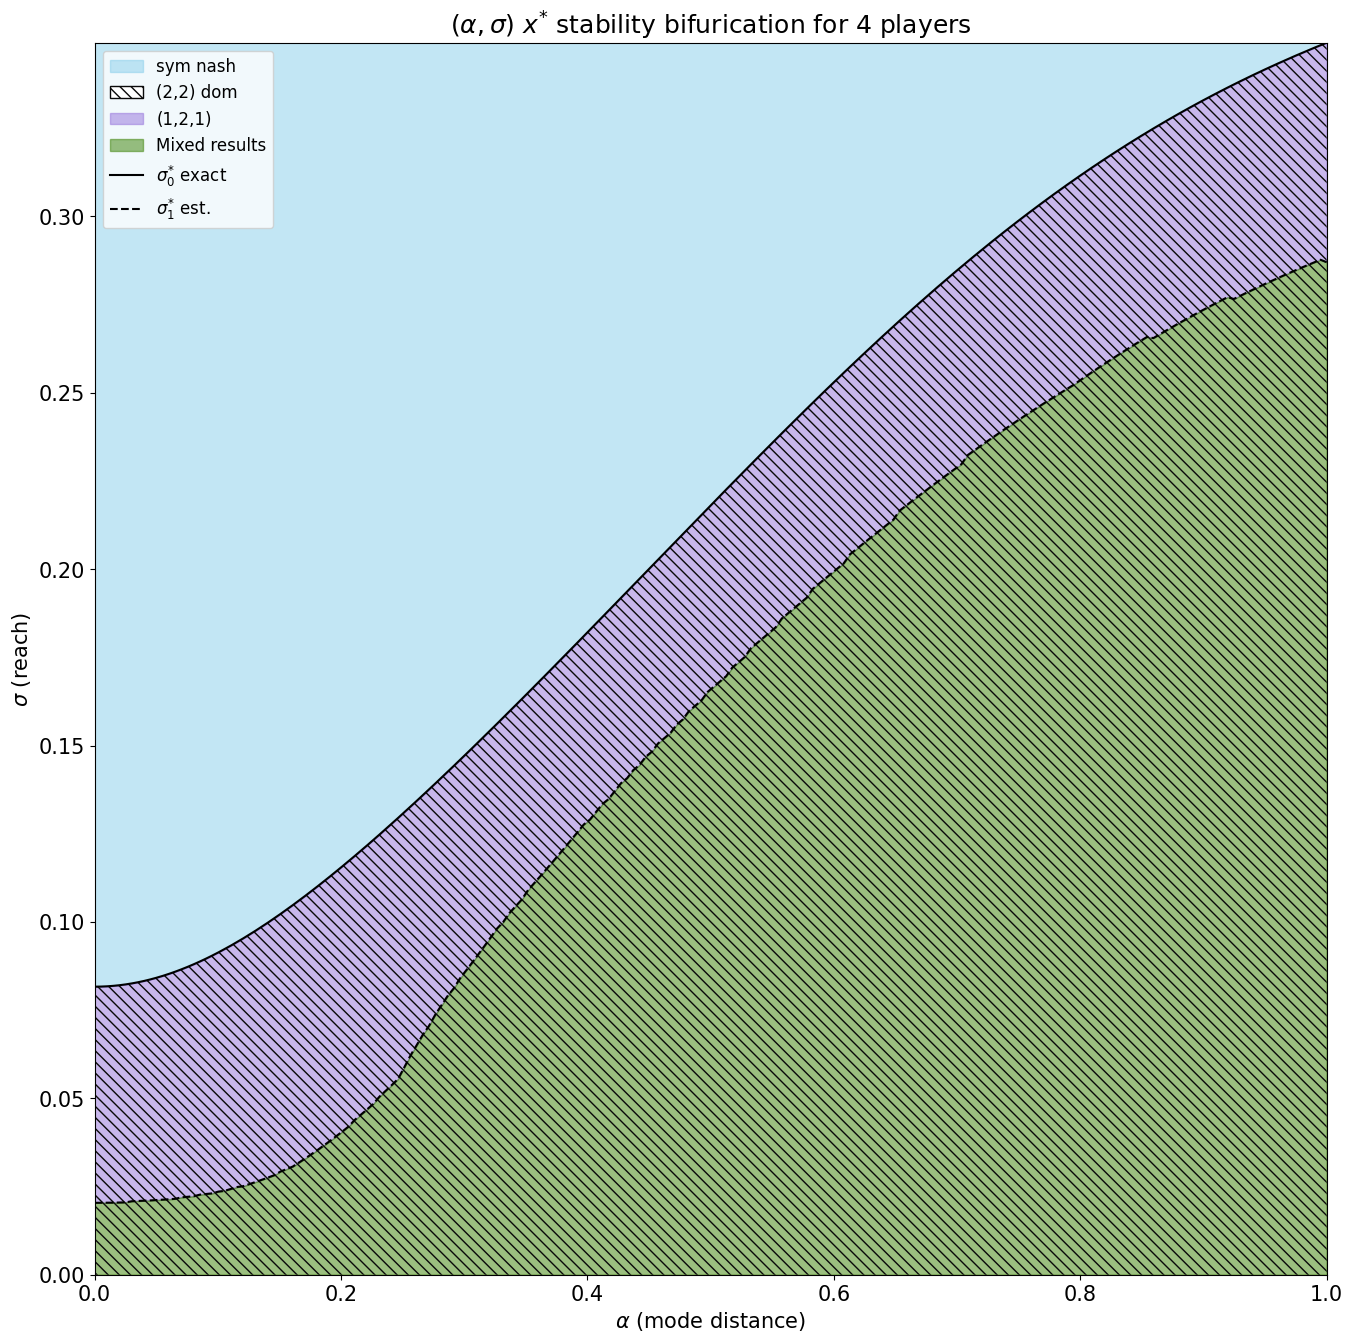

In [45]:
first_order_bifurcation_plot(alpha_st=0,
                             alpha_end=alpha[-1],
                             test_processed=test_processed,
                             alpha_values=alpha,
                             save=True,
                             paper_figure={'paper':True,'section':'3_2_6','figure_id':'fig6_2'})